# 03 – Profile-Outcome Associations

Evaluate relationships between maternal profiles and morbidity outcomes using statistical methods.

# **Import Data + Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Capstone/final_clusters_data.csv', index_col = 0)
full_data = pd.DataFrame(data)
display(full_data.columns)
display(full_data.head())

Index(['mager', 'priorlive', 'priordead', 'priorterm', 'rf_cesarn', 'illb_r',
       'm_ht_in', 'bmi', 'wtgain', 'combgest', 'previs', 'cig_0', 'cig_1',
       'cig_2', 'cig_3', 'rf_pdiab', 'rf_gdiab', 'rf_phype', 'rf_ghype',
       'rf_ehype', 'rf_ppterm', 'ip_gon', 'ip_syph', 'ip_chlam', 'ip_hepb',
       'ip_hepc', 'meduc', 'lbo_rec', 'tbo_rec', 'precare', 'mracehisp_1.0',
       'mracehisp_2.0', 'mracehisp_3.0', 'mracehisp_4.0', 'mracehisp_5.0',
       'mracehisp_6.0', 'mracehisp_7.0', 'mracehisp_Unknown', 'cluster',
       'mm_mtr', 'mm_plac', 'mm_rupt', 'mm_uhyst', 'mm_aicu'],
      dtype='object')

,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,mracehisp_5.0,mracehisp_6.0,mracehisp_7.0,mracehisp_Unknown,cluster,mm_mtr,mm_plac,mm_rupt,mm_uhyst,mm_aicu
0,30,1.0,0.0,0.0,0.0,30.0,66.0,20.799999,4.0,38.0,...,0,0,0,0,1,0,0,0,0,0
1,28,0.0,0.0,0.0,0.0,36.0,67.0,20.400000,40.0,38.0,...,0,1,0,0,2,0,0,0,0,0
2,41,6.0,0.0,2.0,2.0,84.0,67.0,22.700001,28.0,37.0,...,0,0,0,0,0,0,0,0,0,0
3,29,2.0,0.0,0.0,0.0,49.0,61.0,26.400000,28.0,38.0,...,0,0,0,0,2,0,0,0,0,0
4,28,1.0,0.0,2.0,0.0,17.0,64.0,21.500000,31.0,39.0,...,0,0,0,0,2,0,0,0,0,0


# **Create Morbidity Composite Variable**

In [ ]:
# Declare outcome variables
morbidity_vars = ['mm_mtr', 'mm_plac', 'mm_rupt', 'mm_uhyst', 'mm_aicu']

# Re-check for binary (0/1)
full_data[morbidity_vars].value_counts()

mm_mtr  mm_plac  mm_rupt  mm_uhyst  mm_aicu
0       0        0        0         0          3582799
        1        0        0         0            27595
1       0        0        0         0            18059
0       0        0        0         1             4873
1       0        0        0         1             1434
0       0        1        0         0             1208
1       1        0        0         0              538
0       0        0        1         0              533
1       0        0        1         1              416
                                    0              335
                 1        0         0              160
0       0        0        1         1              148
1       0        1        0         1               68
                          1         1               60
0       1        0        0         1               54
1       0        1        1         0               31
        1        0        0         1               27
0       0        1        0         1               26
                          1         0               20
                                    1               20
        1        1        0         0               12
                 0        1         0                5
1       1        0        1         1                4
                 1        1         1                3
                          0         0                3
                 0        1         0                2
0       1        0        1         1                1
                 1        1         1                1
                                    0                1
Name: count, dtype: int64

In [ ]:
# Count for each variable (prsence and no presence)
full_data[morbidity_vars].sum()

,0
mm_mtr,21140
mm_plac,28246
mm_rupt,1613
mm_uhyst,1580
mm_aicu,7135


In [ ]:
# Create Composite Morbidty Outcome variable
full_data['any_morb'] = (full_data[morbidity_vars].sum(axis = 1) > 0).astype(int)

# Check overall morbidity prevalence %
print(f'Total Morbidity Prevalence:', (full_data['any_morb'].mean() * 100).round(4), '%')

Total Morbidity Prevalence: 1.5291 %


/tmp/ipykernel_3370/1704562445.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


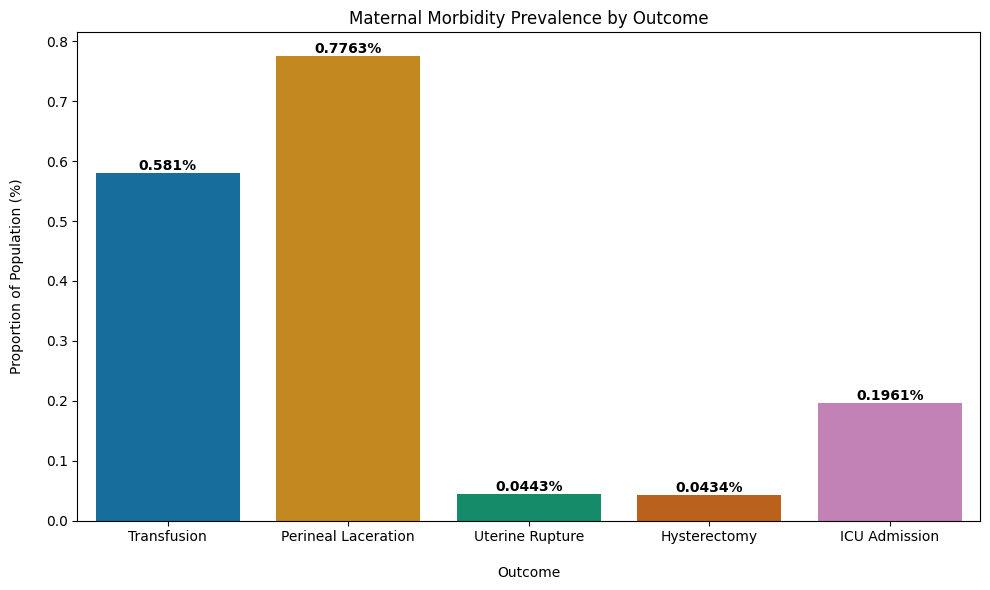

In [ ]:
# Stacked Bar Chart of prevalance per Variable #

# Calculate the proportions of 0 and 1
proportions = (full_data[morbidity_vars].mean() * 100).round(4)

# Convert series to DataFrame for seaborn plotting
proportions_df = proportions.reset_index()
proportions_df.columns = ['Outcome', 'Prevalence']

# Re-label Outcomes
label_map = {
    'mm_mtr': 'Transfusion',
    'mm_plac': 'Perineal Laceration',
    'mm_rupt': 'Uterine Rupture',
    'mm_uhyst': 'Hysterectomy',
    'mm_aicu': 'ICU Admission',
    'any_morb': 'Overall Morbidity'
}

proportions_df['Outcome'] = proportions_df['Outcome'].map(label_map)


# PLotting Bar Chart
plt.figure(figsize = (10, 6))
ax = sns.barplot(
    x = 'Outcome',
    y = 'Prevalence',
    data = proportions_df,
    palette = 'colorblind'
)

# Add percentage labels on the bar
for i, val in enumerate(proportions_df['Prevalence']):
    ax.text(i, val, f'{val}%', ha = 'center', va = 'bottom', fontweight = 'bold')

plt.title('Maternal Morbidity Prevalence by Outcome')
plt.xlabel('\nOutcome')
plt.ylabel('Proportion of Population (%)\n')
plt.tight_layout()
plt.show()

# **Calculate Outcome Rates by Phenotype**

In [ ]:
# Calculate Outcome Rates by Phenotype
morbidity_outcome_rates = full_data.groupby('cluster')[morbidity_vars + ['any_morb']].mean()
display(morbidity_outcome_rates.round(4))

# Export Morbidity Outcome Rate by Cluster
#morbidity_outcome_rates.to_csv('/content/drive/MyDrive/Capstone/MorbOutcomeRateByCluster.csv')

,mm_mtr,mm_plac,mm_rupt,mm_uhyst,mm_aicu,any_morb
cluster,,,,,,
0,0.0083,0.0011,0.0009,0.0011,0.0034,0.0127
1,0.0052,0.0061,0.0003,0.0002,0.0018,0.0129
2,0.0052,0.0114,0.0004,0.0003,0.0014,0.0177
3,0.0067,0.0084,0.0004,0.0005,0.0024,0.0172


In [ ]:
# Outcome Rates per 1000 births
outcome_per1000 = (morbidity_outcome_rates * 1000).round(4)
outcome_per1000.columns = ['Transfusion', 'Perineal Laceration', 'Ruptured Uterus', 'Hysterectomy', 'ICU Admission', 'Total Morbidity' ]
display(outcome_per1000)

,Transfusion,Perineal Laceration,Ruptured Uterus,Hysterectomy,ICU Admission,Total Morbidity
cluster,,,,,,
0,8.2704,1.1227,0.9012,1.1076,3.4320,12.7194
1,5.1887,6.1221,0.3159,0.2480,1.8242,12.9096
2,5.1787,11.4303,0.3651,0.3140,1.4226,17.7482
3,6.7494,8.3641,0.4497,0.4674,2.4221,17.1532


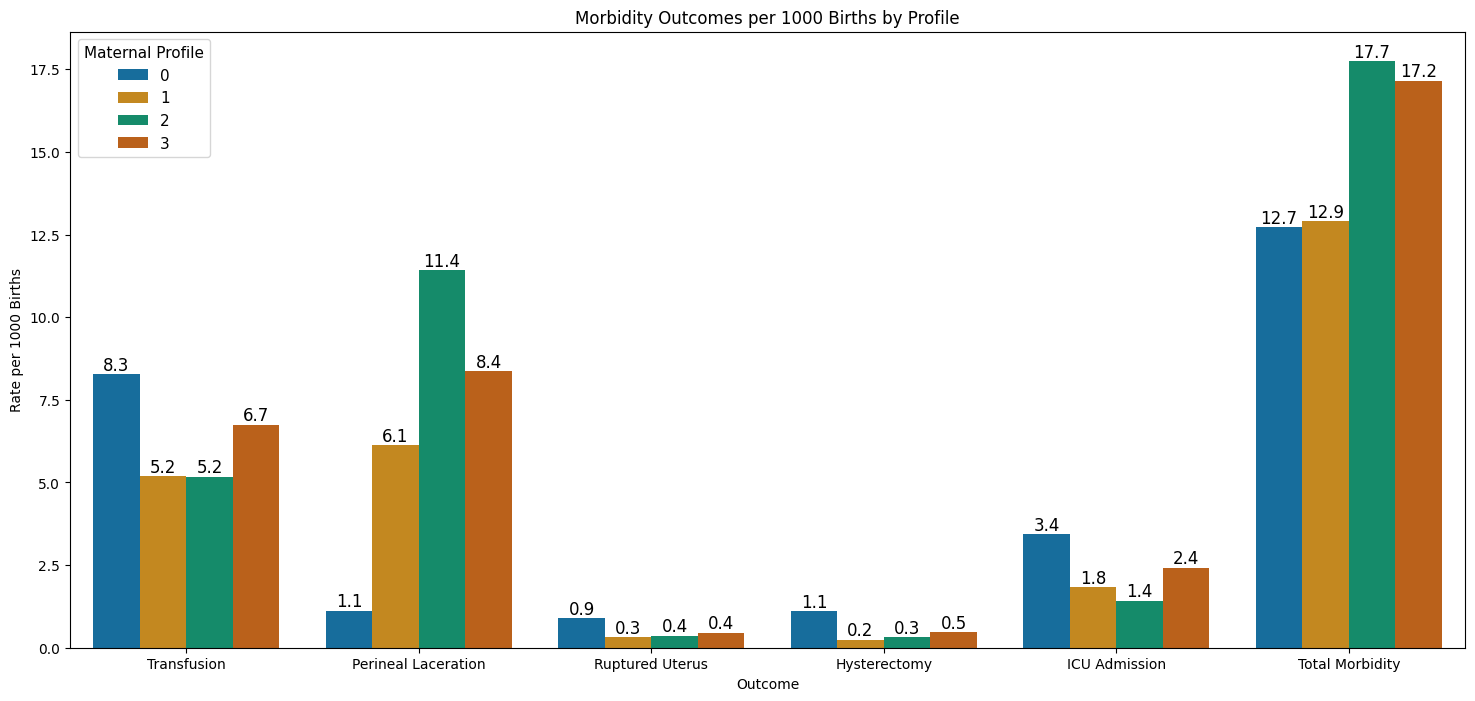

In [ ]:
# Melt data
melted = outcome_per1000.reset_index().melt(
    id_vars='cluster',
    var_name='Outcome',
    value_name='Rate per 1000'
)

plt.figure(figsize=(18,8))

ax = sns.barplot(
    data=melted,
    x='Outcome',
    y='Rate per 1000',
    hue='cluster',
    palette = 'colorblind'
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:  # avoid labeling empty bars
        ax.annotate(
            f'{height:.1f}',
            (p.get_x() + p.get_width()/2., height),
            ha = 'center',
            va = 'bottom',
            fontsize = 12,
            fontweight = 'light'
        )

plt.title('Morbidity Outcomes per 1000 Births by Profile', fontweight = 'light')
plt.xlabel('Outcome')
plt.ylabel('Rate per 1000 Births')

plt.legend(
    title = 'Maternal Profile',
    fontsize = 11,
    title_fontsize = 11,
    loc = 'upper left'
    )
plt.show()

# **Chi-Square Test**

## *Overall Morbidity Chi-Square Test*

In [ ]:
# Chi-Square Test
morb_cont_table = pd.crosstab(
    full_data['cluster'],
    full_data['any_morb']
)

chi2, p, dof, expected = chi2_contingency(morb_cont_table)

print(f'Chi-Square:', chi2.round(4))
print(f'p-value:', p.round(4))
print(f'Degrees of Freedom:', dof)

Chi-Square: 1404.4479
p-value: 0.0
Degrees of Freedom: 3


## *Individual Morbidity Outcomes Chi-Square Test*

In [ ]:
# For loop for chi-square Test of each morbidty outcome
results = []

for outcome in morbidity_vars:
  table = pd.crosstab(full_data['cluster'], full_data[outcome]) # crate contigency table
  chi2, p, dof, expected = chi2_contingency(table) # run the chi-square test
  results.append({
      'Outcome': outcome,
      'Chi-Square': chi2.round(4),
      'p-value': p,
      'DOF': dof,
      'Significance': 'Significant' if p < 0.01 else 'Not Significant'
  })

chi2_results = pd.DataFrame(results)
display(chi2_results)


,Outcome,Chi-Square,p-value,DOF,Significance
0,mm_mtr,855.4389,4.095801e-185,3,Significant
1,mm_plac,6576.7171,0.000000e+00,3,Significant
2,mm_rupt,347.3269,5.655619e-75,3,Significant
3,mm_uhyst,770.7101,9.736144e-167,3,Significant
4,mm_aicu,932.8983,6.471848e-202,3,Significant


# **Create Composite Risk Variables**

## *Socio-demographic Composite*


In [ ]:
full_data['soc_demo_risk'] = (
    (full_data['mager'] < 20) | # Teenage Pregnancy
    (full_data['mager'] >= 35) | # Mature/Advanced Pregnancy
    (full_data['meduc'] < 5) | # Lower Education Threshold (No postsecondary degree)
    (full_data['precare'] >= 4) # Late Prenatal Care (Start after first trimester)
).astype(int)

## *Reproductive Risk Composite*

In [ ]:
full_data['repro_risk'] = (
    (full_data['rf_cesarn'] >= 1).astype(int) + # 1 or more previous cesareans
    (full_data['rf_ppterm'] >= 1).astype(int) + # 1 or more previous preterm births
    (full_data['priorterm'] >= 1).astype(int) + # 1 or more previous pregnancy terminations
    (full_data['priordead'] >= 1).astype(int) + # 1 or more previous fetal deaths
    (full_data['illb_r'] < 18).astype(int) # Short Interpregnancy Interval (Less than 18 months)
) >= 2

## *Metabolic Risk Composite*

In [ ]:
full_data['metabolic_risk'] = (
    (full_data['rf_pdiab'] == 1) |
    (full_data['rf_gdiab'] == 1) |
    (full_data['rf_phype'] == 1) |
    (full_data['rf_ghype'] == 1) |
    (full_data['rf_ehype'] == 1) |
    (full_data['bmi'] >= 30) # Obesity BMI Range
).astype(int)

## *Smoking Behavior Composite*

In [ ]:
full_data['smoking_risk'] = (
    (full_data['cig_0'] > 0) |
    (full_data['cig_1'] > 0) |
    (full_data['cig_2'] > 0) |
    (full_data['cig_3'] > 0)
).astype(int)

## *Infection Risk Composite*

In [ ]:
full_data['infection_risk'] = (
    (full_data['ip_gon'] == 1) |
    (full_data['ip_syph'] == 1) |
    (full_data['ip_chlam'] == 1) |
    (full_data['ip_hepb'] == 1) |
    (full_data['ip_hepc'] == 1)
).astype(int)

# **Composite Risk Prevalence**

## *Overall Prevalence of Each Composite Risk*

,0
soc_demo_risk,0.734238
repro_risk,0.104672
metabolic_risk,0.440972
smoking_risk,0.030517
infection_risk,0.025484


/tmp/ipykernel_3370/2786043823.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_bar = sns.barplot(


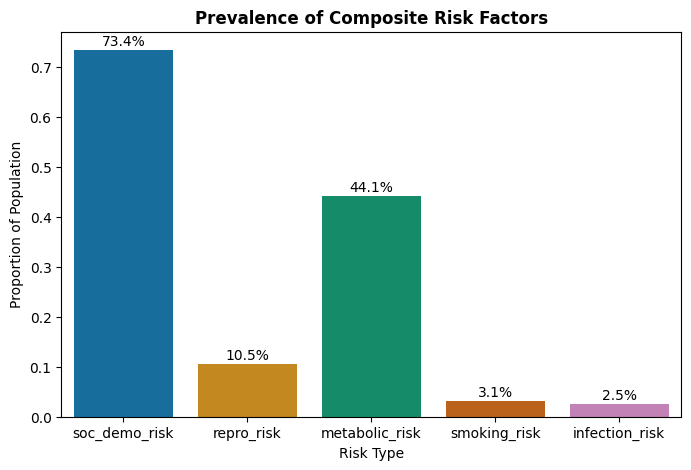

In [ ]:
# Check Composite Prevalence
composite_vars = ['soc_demo_risk','repro_risk','metabolic_risk', 'smoking_risk', 'infection_risk']
display(full_data[composite_vars].mean())

# Prevalence Bar Chart
prevalence = full_data[composite_vars].mean().reset_index()
prevalence.columns = ['Risk Type', 'Prevalence']

plt.figure(figsize=(8,5))

ax_bar = sns.barplot(
    data=prevalence,
    x='Risk Type',
    y='Prevalence',
    palette='colorblind'
)

for p in ax_bar.patches:
    height = p.get_height()
    ax_bar.annotate(
        f'{height:.1%}',
        (p.get_x() + p.get_width() / 2., height + 0.01),
        ha='center',
        fontsize=10
    )

plt.title('Prevalence of Composite Risk Factors', fontweight = 'bold')
plt.ylabel('Proportion of Population')
plt.xlabel('Risk Type')
plt.show()

## *Pearson Coefficient (Pairwise) Correlations*


Pearson Correlation of Risk Composites:


,soc_demo_risk,repro_risk,metabolic_risk,smoking_risk,infection_risk
soc_demo_risk,1.000000,0.070923,0.062568,0.085399,0.071788
repro_risk,0.070923,1.000000,0.076599,0.051719,0.011563
metabolic_risk,0.062568,0.076599,1.000000,0.022910,0.005184
smoking_risk,0.085399,0.051719,0.022910,1.000000,0.077358
infection_risk,0.071788,0.011563,0.005184,0.077358,1.000000


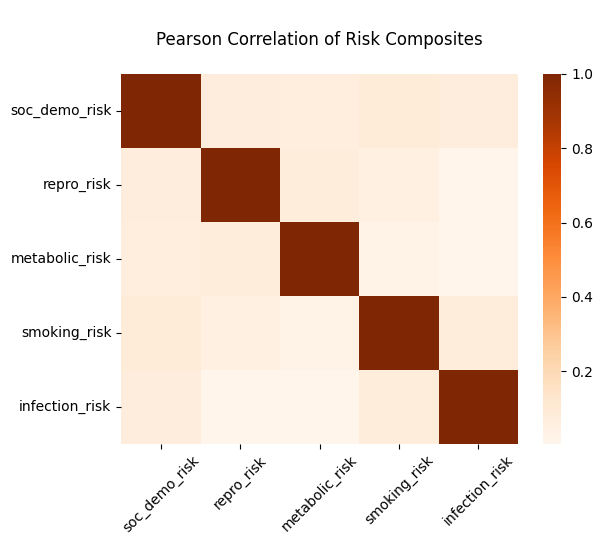

In [ ]:
# Pearson Coefficient (Pairwaise) Correlations
composite_corr = full_data[composite_vars].corr()
print(f'\nPearson Correlation of Risk Composites:')
display(composite_corr)

# Correlation Heatmap
sns.heatmap(data = composite_corr, cmap = 'Oranges')
plt.title('\nPearson Correlation of Risk Composites\n')
plt.xticks(rotation = 45)
plt.show()

## *Composite Risk Prevalence by Phenotype*


Composite Risk Burden by Maternal Profile:


,soc_demo_risk,repro_risk,metabolic_risk,smoking_risk,infection_risk
cluster,,,,,
0,0.913935,0.344924,0.507445,0.115522,0.041206
1,0.840344,0.051055,0.412337,0.009455,0.041726
2,0.583883,0.052566,0.336803,0.015988,0.008256
3,0.740889,0.113412,0.999671,0.020776,0.019257


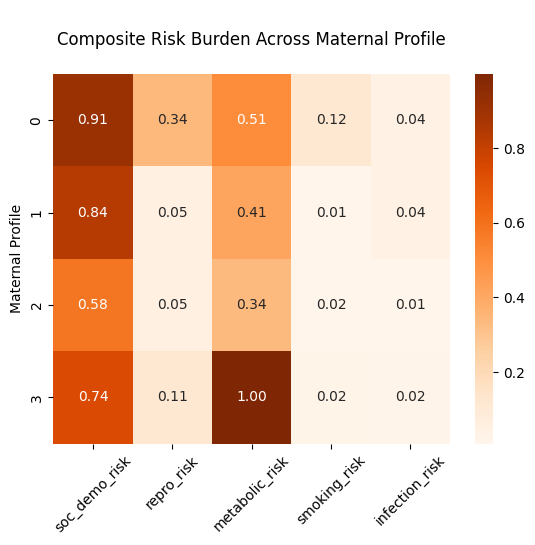

In [ ]:
pheno_comp_risk = full_data.groupby('cluster')[composite_vars].mean()
print('\nComposite Risk Burden by Maternal Profile:')
display(pheno_comp_risk)

sns.heatmap(
    data = pheno_comp_risk,
    cmap = 'Oranges',
    annot = True,
    fmt = '.2f'
)
plt.title('\nComposite Risk Burden Across Maternal Profile\n')
plt.ylabel('Maternal Profile')
plt.xticks(rotation = 45)
plt.show()

## *Calculate Outcome Prevalence by Composite Risks*

,Socio-Demo,Reproductive,Metabolic,Smoking,Infection
Transfusion,0.772091,0.174267,0.536802,0.048723,0.044324
Perineal Laceration,0.562487,0.029243,0.347058,0.012356,0.017418
Uterine Rupture,0.778673,0.373838,0.477371,0.042777,0.034098
Hysterectomy,0.818987,0.298734,0.570253,0.067089,0.036076
ICU Admission,0.819061,0.206027,0.620182,0.061388,0.047372


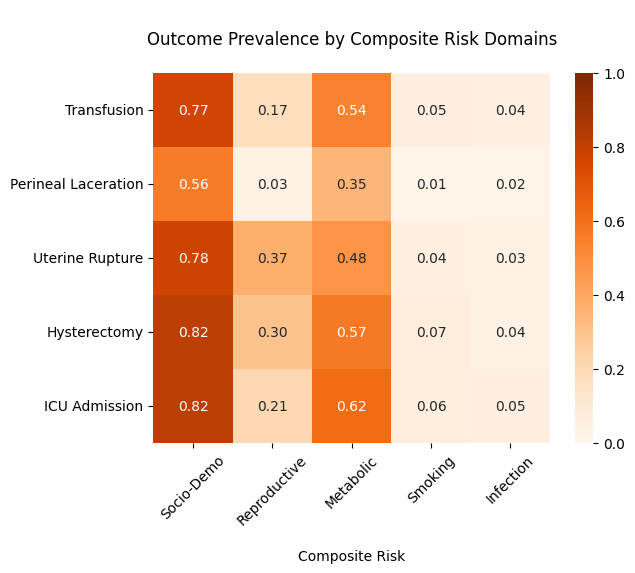

In [ ]:
outcome_composite_sum = pd.DataFrame(columns = composite_vars)

for outcome in morbidity_vars:
  prevalence = full_data.groupby(outcome)[composite_vars].mean().loc[1]
  outcome_composite_sum.loc[outcome] = prevalence

outcome_composite_sum.astype(float).round(4)

outcome_composite_sum = outcome_composite_sum.rename(index = {
    'mm_mtr': 'Transfusion',
    'mm_plac': 'Perineal Laceration',
    'mm_rupt': 'Uterine Rupture',
    'mm_uhyst': 'Hysterectomy',
    'mm_aicu': 'ICU Admission'
})

outcome_composite_sum.columns = ['Socio-Demo', 'Reproductive', 'Metabolic', 'Smoking', 'Infection']

display(outcome_composite_sum)

# Heatmap visualization
sns.heatmap(
    outcome_composite_sum,
    cmap = 'Oranges',
    annot = True,
    fmt = '.2f',
    vmin = 0,
    vmax = 1
)
plt.title('\nOutcome Prevalence by Composite Risk Domains\n')
plt.xticks(rotation = 45)
plt.show()

# **Logistic Regression**

## *Baseline LogReg of Total Morbidity + Composite Risks*

In [ ]:
#Create Predictors
cluster_dummies = pd.get_dummies(full_data['cluster'], drop_first = True) # Cluster 0 will be reference
predictors = pd.concat([cluster_dummies, full_data[composite_vars]], axis = 1)

# Change dtype to int
predictors = predictors.astype(int)
print(predictors.info())
display(predictors.head())

<class 'pandas.core.frame.DataFrame'>
Index: 3638436 entries, 0 to 3638435
Data columns (total 8 columns):
 #   Column          Dtype
---  ------          -----
 0   1               int64
 1   2               int64
 2   3               int64
 3   soc_demo_risk   int64
 4   repro_risk      int64
 5   metabolic_risk  int64
 6   smoking_risk    int64
 7   infection_risk  int64
dtypes: int64(8)
memory usage: 249.8 MB
None


,1,2,3,soc_demo_risk,repro_risk,metabolic_risk,smoking_risk,infection_risk
0,1,0,0,1,0,0,0,0
1,0,1,0,0,0,0,0,0
2,0,0,0,1,1,0,0,0
3,0,1,0,1,0,0,0,0
4,0,1,0,0,1,0,0,0


In [ ]:
#------Import Libraries------#
import statsmodels.api as sm
import numpy as np
import pandas as pd

#------Define Predictors and Outcomes------#
X = predictors
X = sm.add_constant(X)
y = full_data['any_morb'] #Outcome

#------Logistic Regression------#
base_logreg = sm.Logit(y, X).fit()
print('\nLogReg of Total Morbidity and Composite Risks:\n')
print(base_logreg.summary())

#------Extract LogReg Results------#
params = base_logreg.params

#------Odds Ratio------#
base_odds_ratios = np.exp(params)

#------Confidence Intervals------#
base_conf = base_logreg.conf_int()
base_conf['OR_Lower'] = np.exp(base_conf[0])
base_conf['OR_Upper'] = np.exp(base_conf[1])

#------Combine Results for Table------#
base_or_table = pd.concat(
    [base_odds_ratios,
     base_conf[['OR_Lower', 'OR_Upper']],
     base_logreg.pvalues],
     axis = 1
)

base_or_table.columns = ['Odds Ratio', 'CI Lower', 'CI Upper', 'p-value'] #rename the columns

base_or_table = base_or_table.rename(index = {
    1: 'Profile 1',
    2: 'Profile 2',
    3: 'Profile 3',
    'soc_demo_risk': 'Socio-Demo',
    'repro_risk': 'Reproductive',
    'metabolic_risk': 'Metabolic',
    'smoking_risk': 'Smoking',
    'infection_risk': 'Infection'
})

#------Display Table------#
print(f'\nOdds Ratios for Maternal Mordibity Risk by Risk Profile and Domain:\n')
display(base_or_table.round(3))

Optimization terminated successfully.
         Current function value: 0.078787
         Iterations 8

LogReg of Total Morbidity and Composite Risks:

                           Logit Regression Results                           
Dep. Variable:               any_morb   No. Observations:              3638436
Model:                          Logit   Df Residuals:                  3638427
Method:                           MLE   Df Model:                            8
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                0.003943
Time:                        01:19:08   Log-Likelihood:            -2.8666e+05
converged:                       True   LL-Null:                   -2.8780e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -4.2647      0.016   -261.935    

,Odds Ratio,CI Lower,CI Upper,p-value
const,0.014,0.014,0.015,0.0
Profile 1,1.070,1.039,1.103,0.0
Profile 2,1.413,1.373,1.454,0.0
Profile 3,1.345,1.294,1.398,0.0
Socio-Demo,0.795,0.780,0.810,0.0
Reproductive,1.177,1.144,1.211,0.0
Metabolic,1.057,1.038,1.077,0.0
Smoking,1.147,1.091,1.205,0.0
Infection,1.391,1.325,1.462,0.0


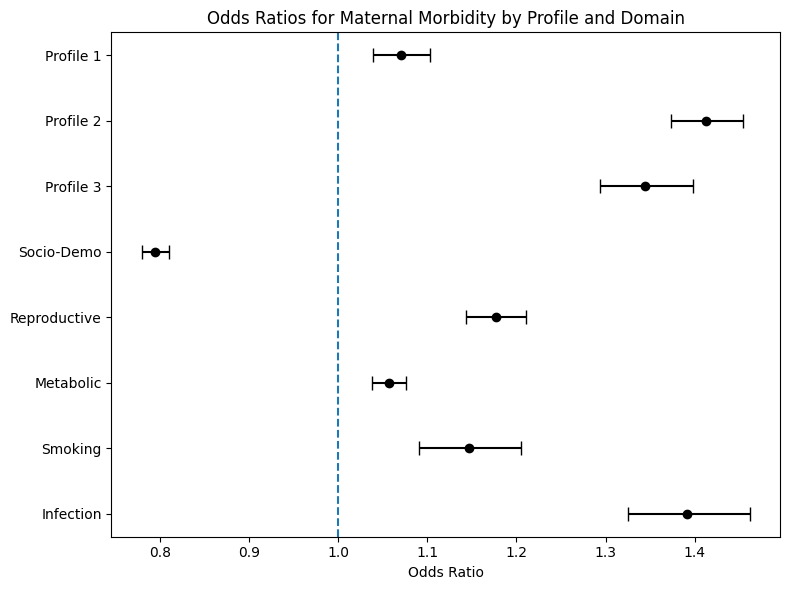

In [ ]:
# Drop intercept
forest_data = base_or_table.copy()
forest_data = forest_data.drop(index='const', errors='ignore')

# Reset index cleanly
forest_data = forest_data.reset_index()
forest_data.rename(columns = {'index': 'Variable'}, inplace = True)

forest_data = forest_data.iloc[::-1].reset_index(drop=True) # reverse order

plt.figure(figsize = (8,6))

y_pos = np.arange(len(forest_data))

plt.errorbar(
    forest_data['Odds Ratio'],
    y_pos,
    xerr=[
        forest_data['Odds Ratio'] - forest_data['CI Lower'],
        forest_data['CI Upper'] - forest_data['Odds Ratio']
    ],
    fmt='o',
    color='black',
    capsize=5
)

plt.axvline(x=1, linestyle='--')

plt.yticks(y_pos, forest_data['Variable'])
plt.xlabel('Odds Ratio')
plt.title('Odds Ratios for Maternal Morbidity by Profile and Domain', fontweight = 'light')
plt.tight_layout()
plt.show()

## *Stratified LogReg of Total Morbidity by Phenotype*

In [ ]:
predictors = full_data[composite_vars]

# Change dtype to int
predictors = predictors.astype(int)
print(predictors.info())
display(predictors.head())

<class 'pandas.core.frame.DataFrame'>
Index: 3638436 entries, 0 to 3638435
Data columns (total 5 columns):
 #   Column          Dtype
---  ------          -----
 0   soc_demo_risk   int64
 1   repro_risk      int64
 2   metabolic_risk  int64
 3   smoking_risk    int64
 4   infection_risk  int64
dtypes: int64(5)
memory usage: 166.6 MB
None


,soc_demo_risk,repro_risk,metabolic_risk,smoking_risk,infection_risk
0,1,0,0,0,0
1,0,0,0,0,0
2,1,1,0,0,0
3,1,0,0,0,0
4,0,1,0,0,0


In [ ]:
strat_models = {}

for cluster in sorted(full_data['cluster'].unique()):
  cluster_data = full_data[full_data['cluster'] == cluster]

  X = predictors.loc[cluster_data.index] # Filter predictors to match the current cluster's data
  X = sm.add_constant(X)
  y = cluster_data['any_morb']

  strat_logreg = sm.Logit(y, X).fit(disp=0)

  strat_odds = np.exp(strat_logreg.params)
  strat_CI = np.exp(strat_logreg.conf_int())
  strat_CI.columns = ['OR_Lower', 'OR_Upper']

  strat_results = pd.concat([strat_odds, strat_CI, strat_logreg.pvalues], axis=1)
  strat_results.columns = ['Odds Ratio', 'CI Lower', 'CI Upper', 'p-value']

  strat_models[cluster] = strat_results

  print(f'Cluster {cluster} LogReg Results:')
  display(strat_results.round(3))

Cluster 0 LogReg Results:


,Odds Ratio,CI Lower,CI Upper,p-value
const,0.007,0.007,0.008,0.0
soc_demo_risk,1.188,1.088,1.297,0.0
repro_risk,1.730,1.653,1.811,0.0
metabolic_risk,1.277,1.220,1.337,0.0
smoking_risk,1.313,1.231,1.402,0.0
infection_risk,1.728,1.581,1.889,0.0


Cluster 1 LogReg Results:


,Odds Ratio,CI Lower,CI Upper,p-value
const,0.013,0.013,0.014,0.000
soc_demo_risk,0.944,0.904,0.985,0.008
repro_risk,1.085,1.012,1.164,0.021
metabolic_risk,1.068,1.034,1.103,0.000
smoking_risk,1.005,0.854,1.183,0.950
infection_risk,1.341,1.249,1.438,0.000


Cluster 2 LogReg Results:


,Odds Ratio,CI Lower,CI Upper,p-value
const,0.021,0.021,0.022,0.000
soc_demo_risk,0.749,0.731,0.767,0.000
repro_risk,0.795,0.750,0.844,0.000
metabolic_risk,0.994,0.969,1.019,0.641
smoking_risk,0.943,0.851,1.044,0.257
infection_risk,1.045,0.916,1.194,0.511


Cluster 3 LogReg Results:


,Odds Ratio,CI Lower,CI Upper,p-value
const,0.060,0.022,0.163,0.000
soc_demo_risk,0.725,0.682,0.770,0.000
repro_risk,0.941,0.858,1.033,0.202
metabolic_risk,0.369,0.135,1.006,0.051
smoking_risk,0.837,0.670,1.046,0.118
infection_risk,1.070,0.870,1.315,0.521


# *Stratified LogReg for Individual Morbidity + Composite Risks*

## *Maternal Transfusion*

In [ ]:
strat_models = {}

for cluster in sorted(full_data['cluster'].unique()):
  cluster_data = full_data[full_data['cluster'] == cluster]

  X = predictors.loc[cluster_data.index] # Filter predictors to match the current cluster's data
  X = sm.add_constant(X)
  y = cluster_data['mm_mtr']

  strat_logreg = sm.Logit(y, X).fit(disp=0)

  strat_odds = np.exp(strat_logreg.params)
  strat_CI = np.exp(strat_logreg.conf_int())
  strat_CI.columns = ['OR_Lower', 'OR_Upper']

  strat_results = pd.concat([strat_odds, strat_CI, strat_logreg.pvalues], axis=1)
  strat_results.columns = ['Odds Ratio', 'CI Lower', 'CI Upper', 'p-value']

  strat_models[cluster] = strat_results

  print(f'Cluster {cluster} LogReg for Maternal Transfusion:')
  display(strat_results.round(3))

## *Perineal Laceration*

In [ ]:
strat_models = {}

for cluster in sorted(full_data['cluster'].unique()):
  cluster_data = full_data[full_data['cluster'] == cluster]

  X = predictors.loc[cluster_data.index] # Filter predictors to match the current cluster's data
  X = sm.add_constant(X)
  y = cluster_data['mm_plac']

  strat_logreg = sm.Logit(y, X).fit(disp=0)

  strat_odds = np.exp(strat_logreg.params)
  strat_CI = np.exp(strat_logreg.conf_int())
  strat_CI.columns = ['OR_Lower', 'OR_Upper']

  strat_results = pd.concat([strat_odds, strat_CI, strat_logreg.pvalues], axis=1)
  strat_results.columns = ['Odds Ratio', 'CI Lower', 'CI Upper', 'p-value']

  strat_models[cluster] = strat_results

  print(f'Cluster {cluster} LogReg for Perineal Laceration:')
  display(strat_results.round(3))

## *Ruptured Uterus*

In [ ]:
strat_models = {}

for cluster in sorted(full_data['cluster'].unique()):
  cluster_data = full_data[full_data['cluster'] == cluster]

  X = predictors.loc[cluster_data.index] # Filter predictors to match the current cluster's data
  X = sm.add_constant(X)
  y = cluster_data['mm_rupt']

  strat_logreg = sm.Logit(y, X).fit(disp=0)

  strat_odds = np.exp(strat_logreg.params)
  strat_CI = np.exp(strat_logreg.conf_int())
  strat_CI.columns = ['OR_Lower', 'OR_Upper']

  strat_results = pd.concat([strat_odds, strat_CI, strat_logreg.pvalues], axis=1)
  strat_results.columns = ['Odds Ratio', 'CI Lower', 'CI Upper', 'p-value']

  strat_models[cluster] = strat_results

  print(f'Cluster {cluster} LogReg for Ruptured Uterus:')
  display(strat_results.round(3))

## *Unplanned Hysterectomy*

In [ ]:
strat_models = {}

for cluster in sorted(full_data['cluster'].unique()):
  cluster_data = full_data[full_data['cluster'] == cluster]

  X = predictors.loc[cluster_data.index] # Filter predictors to match the current cluster's data
  X = sm.add_constant(X)
  y = cluster_data['mm_uhyst']

  strat_logreg = sm.Logit(y, X).fit(disp=0)

  strat_odds = np.exp(strat_logreg.params)
  strat_CI = np.exp(strat_logreg.conf_int())
  strat_CI.columns = ['OR_Lower', 'OR_Upper']

  strat_results = pd.concat([strat_odds, strat_CI, strat_logreg.pvalues], axis=1)
  strat_results.columns = ['Odds Ratio', 'CI Lower', 'CI Upper', 'p-value']

  strat_models[cluster] = strat_results

  print(f'Cluster {cluster} LogReg for Unplanned Hysterectomy:')
  display(strat_results.round(3))

## *ICU Admission*

In [ ]:
strat_models = {}

for cluster in sorted(full_data['cluster'].unique()):
  cluster_data = full_data[full_data['cluster'] == cluster]

  X = predictors.loc[cluster_data.index] # Filter predictors to match the current cluster's data
  X = sm.add_constant(X)
  y = cluster_data['mm_aicu']

  strat_logreg = sm.Logit(y, X).fit(disp=0)

  strat_odds = np.exp(strat_logreg.params)
  strat_CI = np.exp(strat_logreg.conf_int())
  strat_CI.columns = ['OR_Lower', 'OR_Upper']

  strat_results = pd.concat([strat_odds, strat_CI, strat_logreg.pvalues], axis=1)
  strat_results.columns = ['Odds Ratio', 'CI Lower', 'CI Upper', 'p-value']

  strat_models[cluster] = strat_results

  print(f'Cluster {cluster} LogReg for ICU Admission:')
  display(strat_results.round(3))

# **Export Final Dataset for Modeling**

In [ ]:
print(full_data.columns)
display(full_data.head())

In [ ]:
full_data.to_csv('/content/drive/MyDrive/Capstone/final_modeling_data.csv', index = False)